# In-place Y-basis preparation and readout

Prepare a logical |Y⟩ in place, keep it for a few rounds, and read it out in place, with the
construction of Gidney, *Inplace Access to the Surface Code Y Basis*
([arXiv:2302.07395](https://arxiv.org/abs/2302.07395)).
The transition round is `make_y_transition_chunk` in
[`y_transition_round.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/y_transition_round.py)
and the degenerate patch is in
[`y_boundary_patch.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/y_boundary_patch.py);
both are ports of Gidney's published code (CC-BY-4.0, see `VENDORED.md`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pymatching

from lightstim.ir.qec_system import QECSystem
from lightstim.ir.tracker import SyndromeTracker
from lightstim.ir.builder import CircuitBuilder
from lightstim.noise.config import NoiseConfig
from lightstim.qec_code.surface_code.rotated import RotatedSurfaceCode
from lightstim.qec_code.surface_code.rotated.SE_block import RotatedSurfaceCodeExtractionBlock
from lightstim.qec_code.surface_code.rotated.y_boundary_patch import make_degenerate_y_boundary_patch
from lightstim.qec_code.surface_code.rotated.y_transition_round import make_y_transition_chunk


## 1. Preparation, memory rounds, readout

* **Preparation.**  Start from the degenerate patch (d²−1 data qubits, no logical qubit), reset the
  data qubits in a mixed X/Z pattern, run `d//2 + 1` time-reversed rounds, grow to the full patch
  and apply the transition round with `direction='init'`, which prepares Y_L.
* **Memory.**  `memory_rounds` ordinary rounds (default `d`, as in Gidney's reference circuits).
* **Readout.**  Switch back to the degenerate patch's checks and apply the transition round with
  `direction='measure'`, which measures Y_L; `d//2 + 1` more rounds and a mixed-basis data readout
  close the detectors.

The rounds next to the transition use Gidney's interaction order (`'gidney'` and its time reverse
`'gidney_reversed'`); with another order the transition loses one unit of distance.

In [2]:
def y_prep_readout(d, memory_rounds=None):
    r = d if memory_rounds is None else memory_rounds
    rb = d // 2
    system = QECSystem()
    degen = make_degenerate_y_boundary_patch(d)
    gp_degen = system.add_patch(degen, name="P", offset=(0, 0))
    degen_uids = set(gp_degen._registered_stabilizer_uids)
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=0)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    system.register_tracker(tracker)
    system.register_builder(builder)

    def mixed_basis():                          # Z below the anti-diagonal, X above
        out = {}
        for q in system.data_indices:
            x, y = system.qubit_coords[q]
            out[q] = "Z" if (x - 1) // 2 + (y - 1) // 2 < d else "X"
        return out

    # preparation
    builder.initialize(init_dict=mixed_basis(), n=system.num_qubits)
    ch_rev = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney_reversed").circuit
    builder.apply_syndrome_extraction(circuit_chunk=ch_rev, rounds=1)
    builder.apply_syndrome_extraction(circuit_chunk=ch_rev, rounds=rb)
    system.grow_patch("P", RotatedSurfaceCode(distance=d), offset=(0, 0))
    builder.apply_relay_chunk(make_y_transition_chunk(system, "P", gp_degen, direction="init"))
    n = tracker.num_qubits
    y_logical = np.zeros(2 * n, dtype=np.uint8)            # Y_L = X_L * Z_L as a symplectic vector
    for rec in [x for x in system.logical_ops if x.get("patch_name") == "P"]:
        for q, pauli in rec["pauli"].items():
            if pauli in ("X", "Y"):
                y_logical[q] ^= 1
            if pauli in ("Z", "Y"):
                y_logical[n + q] ^= 1
    tracker.declare_logical(y_logical)

    # memory
    ch_fwd = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney").circuit
    if r:
        builder.apply_syndrome_extraction(circuit_chunk=ch_fwd, rounds=r)

    # readout
    system.active_stabilizer_indices.clear()
    system.active_stabilizer_indices.update(degen_uids)
    builder.apply_relay_chunk(make_y_transition_chunk(system, "P", gp_degen, direction="measure"))
    ch_deg = RotatedSurfaceCodeExtractionBlock(system, scheduling="gidney").circuit
    builder.apply_syndrome_extraction(circuit_chunk=ch_deg, rounds=rb)
    builder.apply_syndrome_extraction(circuit_chunk=ch_deg, rounds=1)
    final = {q: b for q, b in mixed_basis().items() if q in gp_degen.data_indices}
    builder.apply_data_readout(final_measurements=final)
    return builder


## 2. Detector slices

`circuit.diagram("detslice-with-ops-svg")` draws the d = 3 circuit tick by tick: the gates of each
tick and the detecting regions at that time, through the preparation, the memory rounds and the
readout.

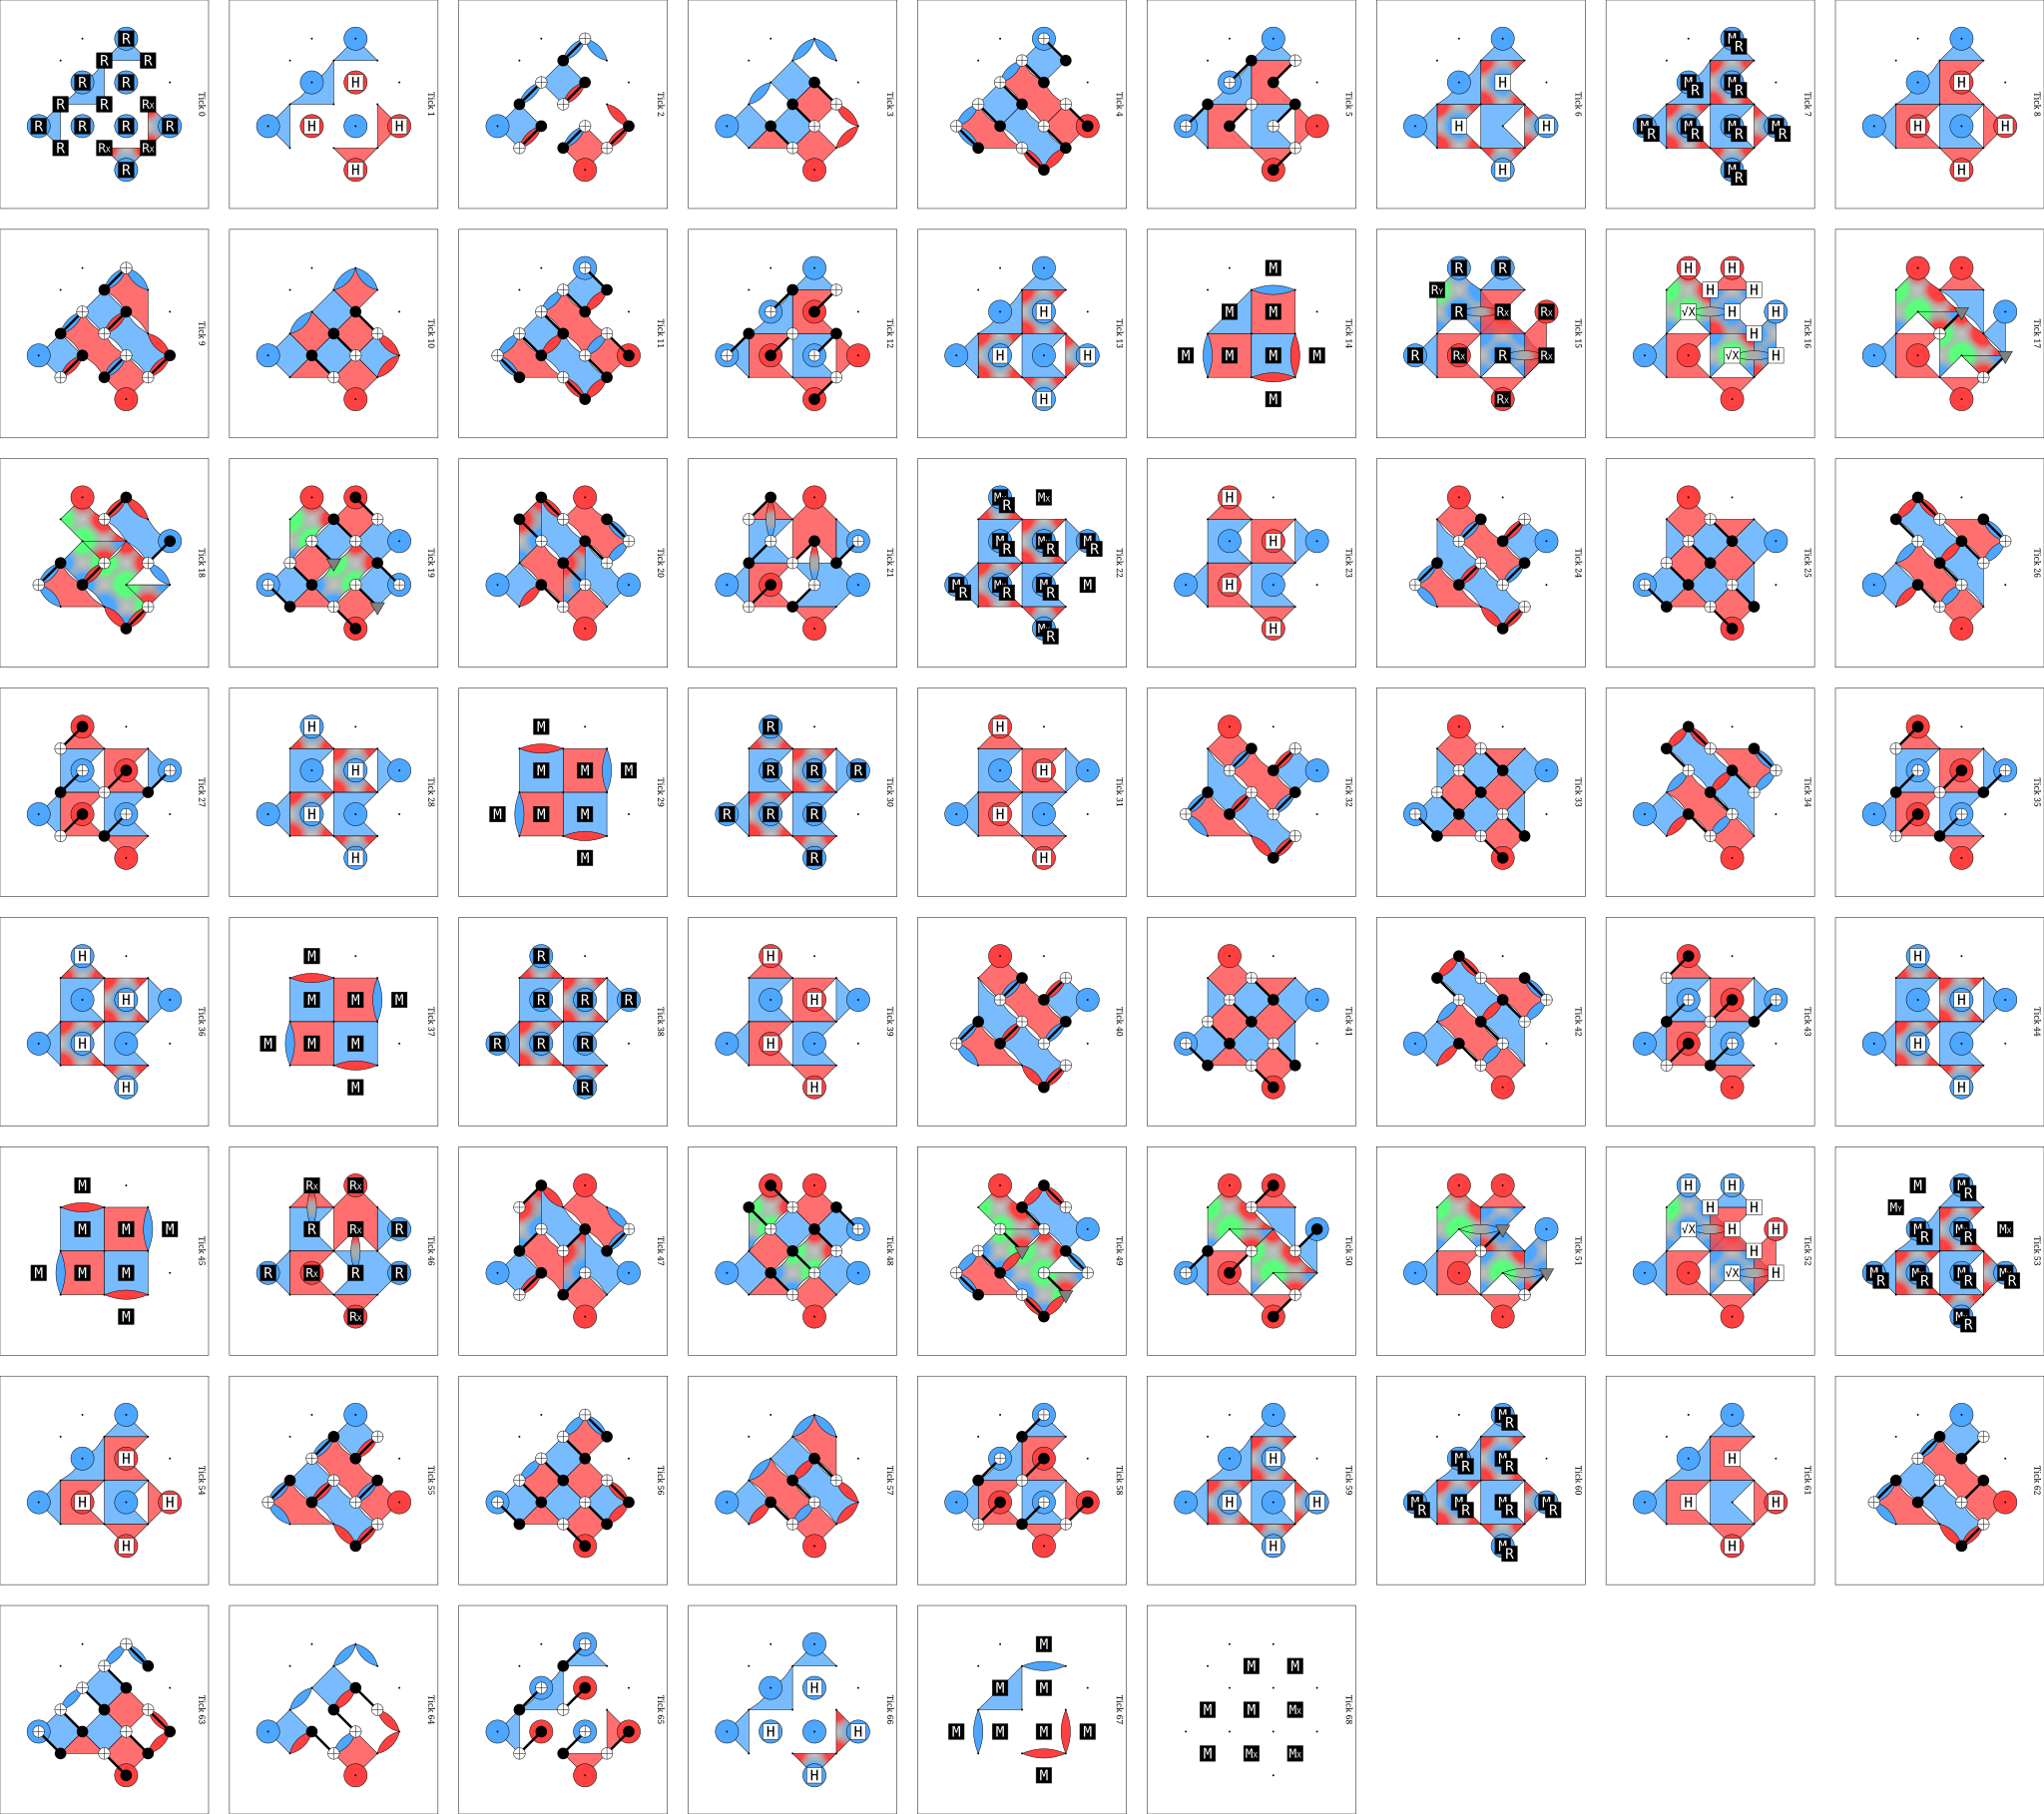

In [3]:
import stim
from IPython.display import SVG, display

builder = y_prep_readout(3)
# the circuit only carries coordinates for the qubits added by the growth step;
# give the other qubits their patch coordinates for the drawing (the circuit itself is unchanged)
has_coords = builder.circuit.get_final_qubit_coordinates()
drawn = stim.Circuit()
for q, (x, y) in sorted(builder.system.qubit_coords.items()):
    if q not in has_coords:
        drawn.append("QUBIT_COORDS", [q], [x, y])
drawn += builder.circuit
display(SVG(str(drawn.diagram("detslice-with-ops-svg"))))


## 3. Checks

At d = 3 with `memory_rounds = d` the circuit has 74 detectors and one observable, the counts of
Gidney's reference circuit.  At p = 0 nothing fires, and under circuit-level depolarizing noise the
shortest graphlike logical error has length `d`, also when the state is read out right after
preparation (`memory_rounds = 0`).

In [4]:
p = 1e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)

for d in (3, 5, 7):
    for r in (d, 0):
        builder = y_prep_readout(d, memory_rounds=r)
        c = builder.circuit
        sample = c.compile_detector_sampler(seed=7).sample(256, append_observables=True)
        noisy = builder.build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
        print(f"d={d} memory_rounds={r}: {c.num_qubits} qubits, {c.num_detectors} detectors, "
              f"{c.num_observables} observable, p=0 silent={not sample.any()}, "
              f"graphlike distance={len(noisy.shortest_graphlike_error())}")


d=3 memory_rounds=3: 19 qubits, 74 detectors, 1 observable, p=0 silent=True, graphlike distance=3
d=3 memory_rounds=0: 19 qubits, 50 detectors, 1 observable, p=0 silent=True, graphlike distance=3


d=5 memory_rounds=5: 53 qubits, 316 detectors, 1 observable, p=0 silent=True, graphlike distance=5


d=5 memory_rounds=0: 53 qubits, 196 detectors, 1 observable, p=0 silent=True, graphlike distance=5


d=7 memory_rounds=7: 103 qubits, 822 detectors, 1 observable, p=0 silent=True, graphlike distance=7


d=7 memory_rounds=0: 103 qubits, 486 detectors, 1 observable, p=0 silent=True, graphlike distance=7


## 4. Logical error rate

Sample the noisy circuit and decode with PyMatching.

In [5]:
def logical_error_rate(circuit, shots, seed=0):
    """Sample the noisy circuit and decode with PyMatching; returns (errors, shots)."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs = circuit.compile_detector_sampler(seed=seed).sample(shots, separate_observables=True)
    errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
    return errors, shots

p = 2e-3
noise = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=p)
for d in (3, 5, 7):
    noisy = y_prep_readout(d).build_noisy_circuit(noise_params=noise, noise_model="circuit_level")
    errors, shots = logical_error_rate(noisy, shots=200_000)
    print(f"p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")


p=0.002 d=3: LER = 1.14e-02 (2280/200000)


p=0.002 d=5: LER = 3.91e-03 (781/200000)


p=0.002 d=7: LER = 1.11e-03 (222/200000)
